# Financial Event Sequencing
**Core Pattern:** Ordered Analytical Window Functions

Top 5 highest-fare trips per day. Each implementation uses its own native API: Pandas uses a chunked nlargest reduction, Polars uses lazy grouped top-k, DuckDB uses max(arg, n) top-N aggregate, Dask uses an ordered shuffle/cumcount path, and Daft uses a partitioned row_number window. Polars is run in both default and streaming mode; DuckDB is run in both default and internally memory-capped mode.

In [1]:
import sys, os

try:
    import datapunk  # noqa: F401
except ImportError:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

os.environ["DAFT_PROGRESS_BAR"] = "0"
import plotly.io as pio

pio.renderers.default = "svg"

from datapunk.reporter import DatapunkReporter

RAM_CAP = 1024  # in MB

reporter = DatapunkReporter(
    small_months=1,
    large_cap_mb=RAM_CAP,
    with_lookup=False,
)

  ⚙ unifying schema across 24 files (20 cols)…
     ✅ unified files cached.


Datapunk Environment
----------------------------------------------------
  OS:        Darwin 25.3.0
  CPU:       Apple M1 Pro (8 cores)
  RAM:       16.0 GB
  Python:    v3.14.6
  Small run: 1 month, uncapped
  Large run: 24 months, cap = 1024 MB (physical RSS)
----------------------------------------------------


## Analytics Functions

In [2]:
# Ordered top-N analytics at scale.
#
# Semantics: top 5 highest-fare trips per pickup day, with a 1-based
# row_number-like fare_rank in descending fare order. The output is tiny; the
# pressure comes from how each engine performs the partitioned order/top-N step
# over the full benchmark window.
#
# Each engine uses its own native API and returns its native materialized output.
# Polars is run twice (default and streaming engine). DuckDB is run twice
# (default and with an explicit memory limit). Dask is run twice (threaded
# scheduler and distributed scheduler with memory limits).

TOP_N = 5
TAXI_COLS = ["tpep_pickup_datetime", "fare_amount"]
OUT_COLS = ["pickup_date", "fare_amount", "fare_rank"]


def _empty_pandas_topn():
    import pandas as pd

    return pd.DataFrame(
        {
            "pickup_date": pd.Series(dtype="datetime64[ns]"),
            "fare_amount": pd.Series(dtype="float64"),
            "fare_rank": pd.Series(dtype="int64"),
        }
    )


def _rank_topn_pandas(df):
    """Pandas-only bounded top-N-per-day helper."""
    if df is None or len(df) == 0:
        return _empty_pandas_topn()

    df = df[["pickup_date", "fare_amount"]].dropna()
    if df.empty:
        return _empty_pandas_topn()

    # groupby().nlargest(TOP_N) keeps only TOP_N candidates per pickup_date instead
    # of sorting/materializing every row in every group.
    s = df.groupby("pickup_date", sort=False)["fare_amount"].nlargest(TOP_N)
    out = s.rename("fare_amount").reset_index(level=0).reset_index(drop=True)
    out = out.sort_values(
        ["pickup_date", "fare_amount"],
        ascending=[True, False],
        kind="mergesort",
    )
    out["fare_rank"] = out.groupby("pickup_date", sort=False).cumcount() + 1
    return out[OUT_COLS]


def _duckdb_materialize(query, params, *, capped=False):
    import duckdb
    import uuid
    from datapunk.fingerprint import DuckDBTableResult

    con = duckdb.connect()
    if capped:
        con.execute(f"SET memory_limit='{int(RAM_CAP * 0.8)}MB'")

    table = f"datapunk_result_{uuid.uuid4().hex}"
    con.execute(f"CREATE TEMP TABLE {table} AS {query}", params)
    return DuckDBTableResult(con=con, table=table)


def window_functions_pandas(file_path):
    import pandas as pd

    candidates = []
    for path in file_path:
        part = pd.read_parquet(path, columns=TAXI_COLS)
        part["pickup_date"] = part["tpep_pickup_datetime"].dt.floor("D")
        # Reduce immediately to per-file daily candidates. Global top-N correctness is
        # preserved because any final top-N row must be in its file-local top-N for
        # the same pickup_date.
        candidates.append(_rank_topn_pandas(part[["pickup_date", "fare_amount"]]))

    result = (
        _rank_topn_pandas(pd.concat(candidates, ignore_index=True))
        if candidates
        else _empty_pandas_topn()
    )
    return result, {"engine": pd.__name__, "version": pd.__version__}


def window_functions_polars(file_path):
    import polars as pl

    lf = (
        pl.scan_parquet(file_path)
        .select(
            pl.col("tpep_pickup_datetime").dt.date().alias("pickup_date"),
            pl.col("fare_amount").cast(pl.Float64),
        )
        .drop_nulls(["pickup_date", "fare_amount"])
        # Expr.top_k is a bounded top-k reduction; output order is not guaranteed,
        # so sort the tiny result before ranking.
        .group_by("pickup_date")
        .agg(pl.col("fare_amount").top_k(TOP_N).alias("fare_amount"))
        .explode("fare_amount")
        .sort(["pickup_date", "fare_amount"], descending=[False, True])
        .with_columns(
            pl.cum_count("fare_amount")
            .over("pickup_date")
            .cast(pl.Int64)
            .alias("fare_rank")
        )
        .select(OUT_COLS)
    )
    result = lf.collect()
    return result, {"engine": pl.__name__, "version": pl.__version__}


def window_functions_polars_streaming(file_path):
    import polars as pl

    lf = (
        pl.scan_parquet(file_path)
        .select(
            pl.col("tpep_pickup_datetime").dt.date().alias("pickup_date"),
            pl.col("fare_amount").cast(pl.Float64),
        )
        .drop_nulls(["pickup_date", "fare_amount"])
        .group_by("pickup_date")
        .agg(pl.col("fare_amount").top_k(TOP_N).alias("fare_amount"))
        .explode("fare_amount")
        .sort(["pickup_date", "fare_amount"], descending=[False, True])
        .with_columns(
            pl.cum_count("fare_amount")
            .over("pickup_date")
            .cast(pl.Int64)
            .alias("fare_rank")
        )
        .select(OUT_COLS)
    )
    result = lf.collect(engine="streaming")
    return result, {"engine": f"{pl.__name__}-streaming", "version": pl.__version__}


def _duckdb_topn_query():
    return f"""
        WITH top_lists AS (
            SELECT
                CAST(tpep_pickup_datetime AS DATE) AS pickup_date,
                max(CAST(fare_amount AS DOUBLE), {TOP_N}) AS fares
            FROM read_parquet($files)
            WHERE tpep_pickup_datetime IS NOT NULL
              AND fare_amount IS NOT NULL
            GROUP BY 1
        ), top_rows AS (
            SELECT pickup_date, unnest(fares) AS fare_amount
            FROM top_lists
        )
        SELECT
            pickup_date,
            fare_amount,
            ROW_NUMBER() OVER (
                PARTITION BY pickup_date
                ORDER BY fare_amount DESC
            ) AS fare_rank
        FROM top_rows
        ORDER BY pickup_date, fare_rank
    """


def window_functions_duckdb(file_path):
    import duckdb

    result = _duckdb_materialize(
        _duckdb_topn_query(),
        {"files": list(map(str, file_path))},
    )
    return result, {"engine": duckdb.__name__, "version": duckdb.__version__}


def window_functions_duckdb_capped(file_path):
    import duckdb

    result = _duckdb_materialize(
        _duckdb_topn_query(),
        {"files": list(map(str, file_path))},
        capped=True,
    )
    return result, {
        "engine": f"{duckdb.__name__}-capped",
        "version": duckdb.__version__,
    }


def _dask_partition_topn(pdf):
    import pandas as pd

    if pdf is None or len(pdf) == 0:
        return _empty_pandas_topn()
    pdf = pdf.loc[:, TAXI_COLS].copy()
    pdf["pickup_date"] = pd.to_datetime(pdf["tpep_pickup_datetime"]).dt.floor("D")
    pdf["fare_amount"] = pdf["fare_amount"].astype("float64")
    return _rank_topn_pandas(pdf[["pickup_date", "fare_amount"]])


def window_functions_dask(file_path):
    import dask
    import dask.dataframe as dd

    ddf = dd.read_parquet(file_path, columns=TAXI_COLS)
    # Two-phase bounded top-N: reduce inside each pandas partition, then run one
    # final small pandas reduction on the candidates. This avoids a full ordered
    # shuffle while staying within Dask's native pandas-partition execution model.
    candidates = ddf.map_partitions(
        _dask_partition_topn, meta=_empty_pandas_topn()
    ).compute()
    result = _rank_topn_pandas(candidates)
    return result, {"engine": dask.__name__, "version": dask.__version__}


def window_functions_daft(file_path):
    import daft
    from daft import Window, col
    import daft.functions as F

    df = daft.read_parquet(list(file_path)).select(
        "tpep_pickup_datetime", "fare_amount"
    )
    df = df.with_column("pickup_date", F.date(col("tpep_pickup_datetime")))
    df = df.filter(F.not_null(col("pickup_date")) & F.not_null(col("fare_amount")))

    # Daft exposes the benchmark pattern directly: partitioned ordered row_number.
    w = Window().partition_by("pickup_date").order_by("fare_amount", desc=True)
    df = df.with_column("fare_rank", F.row_number().over(w))
    df = df.filter(col("fare_rank") <= TOP_N)
    result = df.select("pickup_date", "fare_amount", "fare_rank").collect()
    return result, {"engine": daft.__name__, "version": daft.__version__}


ANALYTICS = [
    window_functions_pandas,
    window_functions_polars,
    window_functions_polars_streaming,
    window_functions_duckdb,
    window_functions_duckdb_capped,
    window_functions_dask,
    window_functions_daft,
]

## Execution & Verification

In [3]:
reporter.run_all(ANALYTICS, target_cols=OUT_COLS)
reporter.export_results(
    suite_id="05",
    title="Financial Event Sequencing",
    core_pattern="Ordered Analytical Window / Top-N by Group",
    description=(
        "Top 5 highest-fare trips per day. Each implementation uses its own "
        "native materialized output: Pandas uses a chunked nlargest reduction, "
        "Polars uses lazy grouped top-k, DuckDB uses max(arg, n) top-N aggregate "
        "materialized to a temp table, Dask uses a two-phase partition-local "
        "top-N reduction, and Daft uses a partitioned row_number window. "
        "Polars: default vs. streaming. DuckDB: default vs. memory-capped."
    ),
)


▶ SMALL run (1 month, cap=none)


    pandas v3.0.3              106 ms  peak 433 MB


    polars v1.41.2              34 ms  peak 302 MB


    polars-streaming v1.41.2      32 ms  peak 292 MB


    duckdb v1.5.4               43 ms  peak 152 MB


...

    polars-streaming v1.41.2        OOM  peak 1076 MB


    duckdb v1.5.4              510 ms  peak 279 MB


    duckdb-capped v1.5.4       488 ms  peak 272 MB


    dask v2026.6.0                OOM  peak 1043 MB


    daft v0.7.15                  OOM  peak 1067 MB
    → consistency: ✅ 2 engine(s) agree (3,678 rows)
📊 exported suite [05] → public/benchmark_results.json


## Analysis

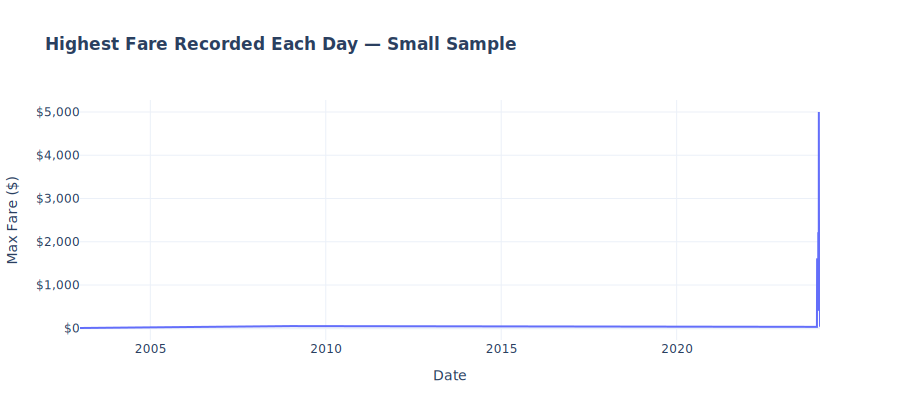

In [4]:
import plotly.express as px

# Visualization is intentionally standardized through pandas on the small run.
# Chart the daily #1 fare from the small sample's top-N output.
reporter.set_analysis_fn(window_functions_pandas, mode="small")
df = reporter.get_analysis_df(OUT_COLS)
df = df[df["fare_rank"] == 1].rename(columns={"fare_amount": "top_fare"})
fig = px.line(
    df,
    x="pickup_date",
    y="top_fare",
    title="<b>Highest Fare Recorded Each Day — Small Sample</b>",
    labels={"pickup_date": "Date", "top_fare": "Max Fare ($)"},
)
fig.update_layout(template="plotly_white", yaxis_tickformat="$,", width=900, height=420)
fig.show()

## Performance Comparison

In [5]:
reporter.show_scorecard("Ordered Window Function Performance")

#### Ordered Window Function Performance — Single Month · Uncapped

| Engine                   | Time    | Velocity   | Peak RAM   | Stress   |
|:-------------------------|:--------|:-----------|:-----------|:---------|
| pandas v3.0.3            | 0.1062s | 1.2×       | 433 MB     | —        |
| daft v0.7.15             | 0.1037s | 1.3×       | 227 MB     | —        |
| dask v2026.6.0           | 0.1307s | 1.0×       | 472 MB     | —        |
| duckdb v1.5.4            | 0.0428s | 3.1×       | 152 MB     | —        |
| duckdb-capped v1.5.4     | 0.0365s | 3.6×       | 157 MB     | —        |
| polars v1.41.2           | 0.0339s | 3.9×       | 302 MB     | —        |
| polars-streaming v1.41.2 | 0.0324s | **4.0×**   | 292 MB     | —        |

*❌ daft v0.7.15 differs from pandas v3.0.3 (pickup_date: categorical distribution differs)*

#### Ordered Window Function Performance — Full Window · 1024 MB Cap

| Engine                   | Time    | Velocity   | Peak RAM   | Stress   |
|:-------------------------|:--------|:-----------|:-----------|:---------|
| pandas v3.0.3            | **OOM** | —          | ≥1040 MB   | ≥1.02    |
| daft v0.7.15             | **OOM** | —          | ≥1067 MB   | ≥1.04    |
| dask v2026.6.0           | **OOM** | —          | ≥1043 MB   | ≥1.02    |
| duckdb v1.5.4            | 0.5103s | 1.0×       | 279 MB     | 0.27     |
| duckdb-capped v1.5.4     | 0.4876s | **1.0×**   | 272 MB     | 0.27     |
| polars v1.41.2           | **OOM** | —          | ≥1043 MB   | ≥1.02    |
| polars-streaming v1.41.2 | **OOM** | —          | ≥1076 MB   | ≥1.05    |

*✅ 2 engine(s) agree (3,678 rows)*